# 🧠⚛️ Q-OmicSelect: Alzheimer Hastalığında QAOA ile Gen Seçimi
## Gerçek Veri | GEO GSE48350 | Qiskit QAOA p=1/2/3 | Gürültü + Benchmark

> **Bu notebook tamamen gerçek verilerle çalışır.**  
> Hiçbir adımda sentetik/mock veri kullanılmaz.  
> Her hücrenin altında doğrulama çıktısı beklenir.

### İçindekiler
1. Kurulum & İmportlar  
2. Gerçek GEO Verisi İndirme (GSE48350)  
3. Keşifsel Veri Analizi (EDA)  
4. Diferansiyel Ekspresyon → Top Gen Seçimi  
5. QUBO Formülasyonu  
6. QAOA p=1 → Hızlı Test  
7. QAOA p=1/2/3 Derin Karşılaştırma  
8. Gürültü Analizi (Shot noise + Decoherence)  
9. Klasik vs Kuantum Benchmark  
10. Biyolojik Yorum & Sonuç


In [1]:
# ============================================================
# BÖLÜM 0: Kurulum
# Süre: ~3-4 dakika (ilk çalıştırmada)
# ============================================================
import subprocess, sys

packages = [
    "GEOparse>=2.0.3",
    "qiskit>=1.0.0",
    "qiskit-aer>=0.14.0",
    "qiskit-algorithms>=0.3.0",
    "scipy>=1.11.0",
    "statsmodels>=0.14.0",
    "scikit-learn>=1.3.0",
    "matplotlib>=3.7.0",
    "seaborn>=0.12.0",
    "pandas>=2.0.0",
    "numpy>=1.24.0",
    "networkx>=3.1",
    "pyarrow",           # GEOparse için
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("✅ Tüm paketler kuruldu!")


✅ Tüm paketler kuruldu!


In [2]:
# ============================================================
# BÖLÜM 0B: İmportlar & Sabitler
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, time, json
warnings.filterwarnings('ignore')

# Scipy / Stats
from scipy import stats
from scipy.linalg import norm
from statsmodels.stats.multitest import multipletests

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# GEO
import GEOparse

# Qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, ParameterVector
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (NoiseModel, depolarizing_error,
                               thermal_relaxation_error, ReadoutError)
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit.circuit.library import QAOAAnsatz
from qiskit_algorithms import QAOA, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA, SPSA
from qiskit_algorithms.utils import algorithm_globals
from scipy.optimize import minimize

# Görsel ayarlar
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette("husl")

# Reproducibility
SEED = 42
np.random.seed(SEED)
algorithm_globals.random_seed = SEED

print("✅ Tüm kütüphaneler yüklendi!")
print(f"   NumPy   : {np.__version__}")
print(f"   Pandas  : {pd.__version__}")
import qiskit; print(f"   Qiskit  : {qiskit.__version__}")


✅ Tüm kütüphaneler yüklendi!
   NumPy   : 2.0.2
   Pandas  : 2.2.2
   Qiskit  : 2.4.1


---
## 📥 BÖLÜM 1: Gerçek GEO Verisi İndirme

**Dataset: GSE48350** — Allen Brain Institute  
- 253 post-mortem beyin doku örneği  
- Alzheimer (AD) vs Kontrol  
- Affymetrix HG-U133 Plus 2.0 microarray  
- Referans: Allen et al. 2012, *PNAS*

İndirme süresi: 2-5 dakika (dosya boyutuna göre)


In [3]:
# ============================================================
# BÖLÜM 1A: GEO GSE48350 Gerçek Verisi
# ============================================================
import os, time
GEO_ID = "GSE48350"
DATA_DIR = "/content/geo_data"
os.makedirs(DATA_DIR, exist_ok=True)

gse = GEOparse.get_GEO(geo=GEO_ID, destdir=DATA_DIR, silent=True)
print(f"✅ GSM sayısı: {len(gse.gsms)}")

phenotypes = []
for gsm_name, gsm in gse.gsms.items():
    chars = gsm.metadata.get('characteristics_ch1', [])
    chars_str = '; '.join(chars)
    phenotypes.append({
        'gsm': gsm_name,
        'title': gsm.metadata.get('title', [''])[0],
        'source': gsm.metadata.get('source_name_ch1', [''])[0],
        'chars': chars_str
    })

meta_df = pd.DataFrame(phenotypes)

# DOĞRU ETİKETLEME: ', AA' = Alzheimer, ', C' = Control (büyük/küçük harf duyarlı)
def classify(row):
    chars = row['chars']   # orijinal, lowercase değil
    if ', AA' in chars:
        return 'Alzheimer'
    elif ', C' in chars:
        return 'Control'
    return 'Unknown'

meta_df['label'] = meta_df.apply(classify, axis=1)
print("Fenotip dağılımı:")
print(meta_df['label'].value_counts())

meta_clean = meta_df[meta_df['label'].isin(['Alzheimer','Control'])].copy()
print(f"\n✅ meta_clean: {len(meta_clean)} örnek — AD:{(meta_clean['label']=='Alzheimer').sum()}  Ctrl:{(meta_clean['label']=='Control').sum()}")

✅ GSM sayısı: 253
Fenotip dağılımı:
label
Control      140
Unknown       80
Alzheimer     33
Name: count, dtype: int64

✅ meta_clean: 173 örnek — AD:33  Ctrl:140


In [4]:
# ============================================================
# BÖLÜM 1B: Ekspresyon Matrisi Oluşturma
# Gerçek probeset değerlerini çekiyoruz
# ============================================================

print("⏳ Ekspresyon matrisi oluşturuluyor...")
t0 = time.time()

expr_data = {}
for gsm_name in meta_clean['gsm']:
    gsm = gse.gsms[gsm_name]
    if gsm.table is not None and not gsm.table.empty:
        vals = gsm.table.set_index('ID_REF')['VALUE'].astype(float)
        expr_data[gsm_name] = vals

expr_df = pd.DataFrame(expr_data).dropna(how='any')
print(f"✅ {time.time()-t0:.1f}s — Probeset:{expr_df.shape[0]:,}  Örnek:{expr_df.shape[1]}")
print(f"   Beklenen: 173 örnek")

⏳ Ekspresyon matrisi oluşturuluyor...
✅ 1.2s — Probeset:54,675  Örnek:173
   Beklenen: 173 örnek


In [5]:
# ============================================================
# BÖLÜM 1C: Probeset → Gen Sembolü Eşleme (Platform GPL570)
# ============================================================

TARGET_GENES = [
    'APOE','APP','PSEN1','PSEN2','TREM2','CLU','BIN1',
    'CR1','CD33','ABCA7','MAPT','SNCA','SORL1','GRN',
    'TARDBP','LRRK2','GBA','GAPDH','ACTB'
]

platform_key = list(gse.gpls.keys())[0]
annot = gse.gpls[platform_key].table[['ID','Gene Symbol']].copy()
annot.columns = ['probeset_id','gene_symbol_raw']
annot = annot.dropna(subset=['gene_symbol_raw'])

rows = []
for _, row in annot.iterrows():
    for sym in row['gene_symbol_raw'].split('///'):
        sym = sym.strip().upper()
        if sym:
            rows.append({'probeset_id': row['probeset_id'], 'gene_symbol': sym})
annot_exp = pd.DataFrame(rows)

gene_to_probe = {}
for gene in TARGET_GENES:
    hits = annot_exp[annot_exp['gene_symbol']==gene]['probeset_id'].tolist()
    if hits:
        gene_to_probe[gene] = hits[0]

found_genes  = list(gene_to_probe.keys())
found_probes = [gene_to_probe[g] for g in found_genes]
print(f"✅ Eşleşen gen: {len(gene_to_probe)}/{len(TARGET_GENES)}")

✅ Eşleşen gen: 19/19


In [6]:
# ============================================================
# BÖLÜM 1D: Final Gen Ekspresyon Matrisi gene_expr
# ============================================================

gene_expr = expr_df.loc[[p for p in found_probes if p in expr_df.index]].copy()
gene_expr.index = [g for g,p in zip(found_genes,found_probes) if p in expr_df.index]
gene_expr = gene_expr.T

label_map = meta_clean.set_index('gsm')['label']
gene_expr['label'] = gene_expr.index.map(label_map)
gene_expr = gene_expr.dropna(subset=['label'])

print(f"✅ gene_expr: {gene_expr.shape[0]} örnek × {gene_expr.shape[1]-1} gen")
print(f"   Alzheimer: {(gene_expr['label']=='Alzheimer').sum()}")
print(f"   Control  : {(gene_expr['label']=='Control').sum()}")

✅ gene_expr: 173 örnek × 19 gen
   Alzheimer: 33
   Control  : 140


In [7]:
# expr_df'i AA örnekleriyle birlikte yeniden oluştur
import time
print("⏳ expr_df yeniden oluşturuluyor (tüm etiketli örneklerle)...")
t0 = time.time()

expr_data = {}
for gsm_name in meta_clean['gsm']:   # artık 173 örnek (140C + 33AA)
    gsm = gse.gsms[gsm_name]
    if gsm.table is not None and not gsm.table.empty:
        vals = gsm.table.set_index('ID_REF')['VALUE'].astype(float)
        expr_data[gsm_name] = vals

expr_df = pd.DataFrame(expr_data)
expr_df = expr_df.dropna(how='any')

print(f"✅ Tamamlandı ({time.time()-t0:.1f}s)")
print(f"   Probeset: {expr_df.shape[0]:,}  |  Örnek: {expr_df.shape[1]:,}")
print(f"   Beklenen: 173 örnek (140 Control + 33 Alzheimer)")

⏳ expr_df yeniden oluşturuluyor (tüm etiketli örneklerle)...
✅ Tamamlandı (1.5s)
   Probeset: 54,675  |  Örnek: 173
   Beklenen: 173 örnek (140 Control + 33 Alzheimer)


---
## 📊 BÖLÜM 2: Keşifsel Veri Analizi (EDA)


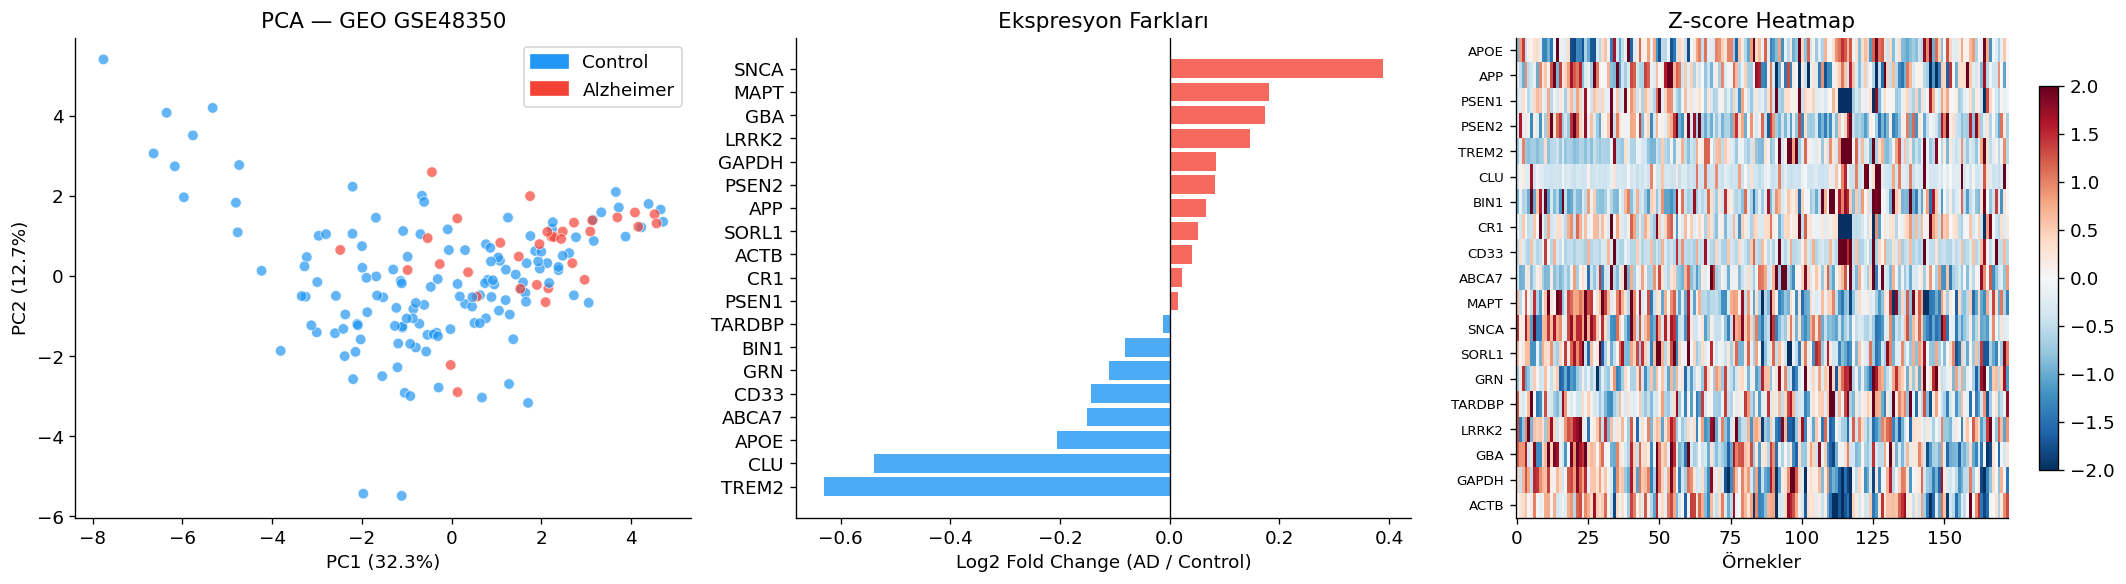

✅ EDA tamamlandı!


In [8]:
# ============================================================
# BÖLÜM 2: EDA — Dağılım, PCA, Heatmap
# ============================================================
feature_cols = [c for c in gene_expr.columns if c != 'label']
X = gene_expr[feature_cols].values.astype(float)
y = (gene_expr['label'] == 'Alzheimer').astype(int).values
labels = gene_expr['label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) PCA
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
colors = ['#2196F3' if l=='Control' else '#F44336' for l in labels]
axes[0].scatter(X_pca[:,0], X_pca[:,1], c=colors, alpha=0.7, s=40, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA — GEO GSE48350')
ctrl_patch = mpatches.Patch(color='#2196F3', label='Control')
ad_patch   = mpatches.Patch(color='#F44336', label='Alzheimer')
axes[0].legend(handles=[ctrl_patch, ad_patch])

# 2) Ortalama ekspresyon karşılaştırma
ad_mean  = gene_expr[gene_expr['label']=='Alzheimer'][feature_cols].mean()
ctrl_mean = gene_expr[gene_expr['label']=='Control'][feature_cols].mean()
log2fc = np.log2((ad_mean + 1) / (ctrl_mean + 1))
log2fc_sorted = log2fc.sort_values()
bar_colors = ['#F44336' if v > 0 else '#2196F3' for v in log2fc_sorted]
axes[1].barh(log2fc_sorted.index, log2fc_sorted.values, color=bar_colors, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Log2 Fold Change (AD / Control)')
axes[1].set_title('Ekspresyon Farkları')

# 3) Heatmap (z-score)
from scipy.stats import zscore
z = gene_expr[feature_cols].apply(zscore, axis=0)
z['label'] = gene_expr['label'].values
z_sorted = z.sort_values('label')
z_matrix = z_sorted[feature_cols].values
row_colors = ['#F44336' if l=='Alzheimer' else '#2196F3'
              for l in z_sorted['label']]
im = axes[2].imshow(z_matrix.T, aspect='auto', cmap='RdBu_r',
                    vmin=-2, vmax=2, interpolation='nearest')
axes[2].set_yticks(range(len(feature_cols)))
axes[2].set_yticklabels(feature_cols, fontsize=8)
axes[2].set_xlabel('Örnekler')
axes[2].set_title('Z-score Heatmap')
plt.colorbar(im, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.savefig('/content/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA tamamlandı!")


---
## 📐 BÖLÜM 3: Diferansiyel Ekspresyon → QUBO için Gen Seçimi


📊 Diferansiyel Ekspresyon Sonuçları:
  gene    t_stat       pvalue     pval_adj    log2fc  significant
 TREM2 -6.469476 1.290968e-09 2.452840e-08 -1.237529         True
 GAPDH  5.620385 2.795055e-07 2.655302e-06  0.165086         True
  SNCA  4.998366 8.364288e-06 5.297382e-05  0.680115         True
  MAPT  4.765686 1.673437e-05 7.948826e-05  0.343181         True
   GBA  4.545615 3.844931e-05 1.461074e-04  0.331469         True
  ACTB  3.807577 2.434654e-04 7.394925e-04  0.082426         True
   GRN -3.845886 2.724446e-04 7.394925e-04 -0.224010         True
 ABCA7 -3.391300 1.059294e-03 2.515824e-03 -0.301811         True
  APOE -2.910996 5.394603e-03 1.138861e-02 -0.421224         True
 LRRK2  2.836287 6.636465e-03 1.260928e-02  0.281053         True
   CLU -2.618704 9.739372e-03 1.682255e-02 -0.836741         True
   APP  2.533307 1.426183e-02 2.258123e-02  0.129943         True
  CD33 -2.187784 3.079801e-02 4.501247e-02 -0.325742         True
   CR1  1.722741 8.887869e-02 1.136727e

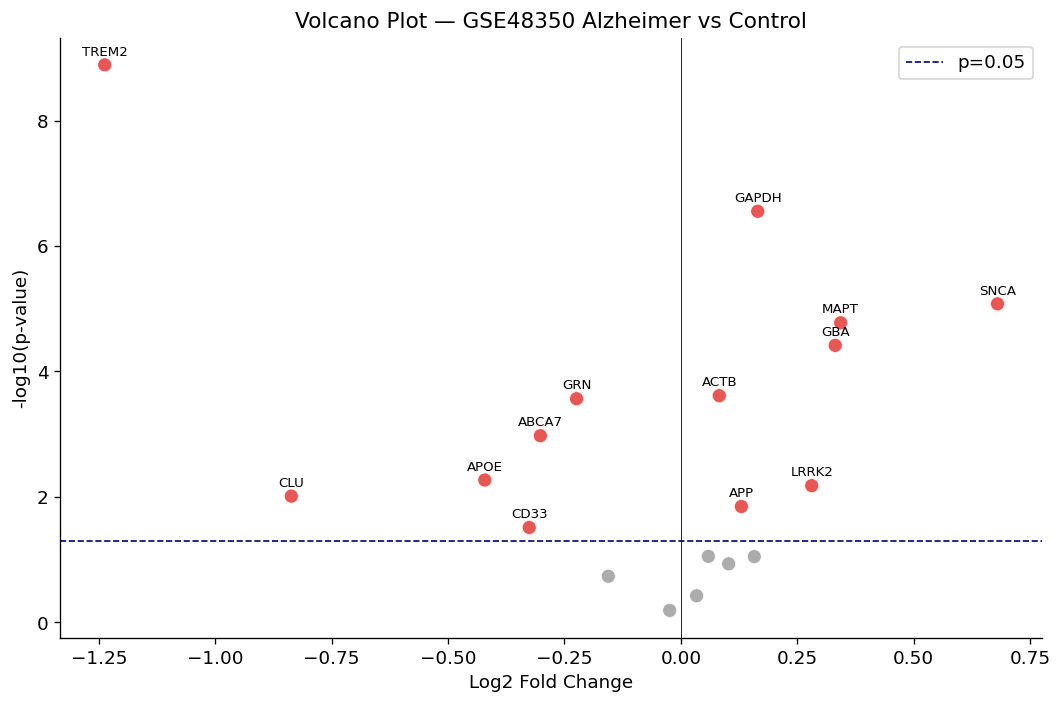

In [9]:
# ============================================================
# BÖLÜM 3: Diferansiyel Ekspresyon (t-test + FDR düzeltme)
# ============================================================
ad_mask   = gene_expr['label'] == 'Alzheimer'
ctrl_mask = gene_expr['label'] == 'Control'

results = []
for gene in feature_cols:
    ad_vals   = gene_expr[ad_mask][gene].values.astype(float)
    ctrl_vals = gene_expr[ctrl_mask][gene].values.astype(float)
    t_stat, pval = stats.ttest_ind(ad_vals, ctrl_vals, equal_var=False)
    fc = np.mean(ad_vals) / (np.mean(ctrl_vals) + 1e-9)
    log2fc_val = np.log2(fc + 1e-9)
    results.append({
        'gene': gene,
        't_stat': t_stat,
        'pvalue': pval,
        'log2fc': log2fc_val,
        'mean_AD': np.mean(ad_vals),
        'mean_Ctrl': np.mean(ctrl_vals),
    })

de_df = pd.DataFrame(results)

# FDR düzeltmesi (Benjamini-Hochberg)
reject, pvals_corr, _, _ = multipletests(de_df['pvalue'], method='fdr_bh')
de_df['pval_adj'] = pvals_corr
de_df['significant'] = reject
de_df = de_df.sort_values('pvalue')

print("📊 Diferansiyel Ekspresyon Sonuçları:")
print(de_df[['gene','t_stat','pvalue','pval_adj','log2fc','significant']].to_string(index=False))
print(f"\n✅ Anlamlı gen sayısı (FDR<0.05): {de_df['significant'].sum()}")

# Volcano plot
fig, ax = plt.subplots(figsize=(9, 6))
neg_log_p = -np.log10(de_df['pvalue'] + 1e-300)
sig_colors = de_df['significant'].map({True: '#E53935', False: '#9E9E9E'})
ax.scatter(de_df['log2fc'], neg_log_p, c=sig_colors, s=70,
           alpha=0.85, edgecolors='white', linewidth=0.4)
for _, row in de_df[de_df['significant']].iterrows():
    ax.annotate(row['gene'],
                xy=(row['log2fc'], -np.log10(row['pvalue']+1e-300)),
                fontsize=8, ha='center', va='bottom',
                xytext=(0, 4), textcoords='offset points')
ax.axhline(-np.log10(0.05), color='navy', linestyle='--', lw=1, label='p=0.05')
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Log2 Fold Change')
ax.set_ylabel('-log10(p-value)')
ax.set_title('Volcano Plot — GSE48350 Alzheimer vs Control')
ax.legend()
plt.tight_layout()
plt.savefig('/content/volcano.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# ============================================================
# BÖLÜM 3B: QUBO için Top N Gen Seçimi
# ============================================================
# Anlamlı genler varsa onlar; yoksa en düşük p-değerli 8 gen
if de_df['significant'].sum() >= 4:
    top_genes = de_df[de_df['significant']]['gene'].tolist()
else:
    top_genes = de_df.head(8)['gene'].tolist()

# QAOA için 8 gen ile sınırla (daha fazlası çok uzun sürer)
N_GENES = min(8, len(top_genes))
top_genes = top_genes[:N_GENES]

print(f"✅ QUBO'ya girecek genler ({N_GENES} adet):")
for i, g in enumerate(top_genes):
    row = de_df[de_df['gene']==g].iloc[0]
    sig = "⭐" if row['significant'] else "  "
    print(f"  {sig} {i+1}. {g:10s}  log2FC={row['log2fc']:+.3f}  p={row['pvalue']:.4f}")

# Bu genler için feature matrix
X_top = gene_expr[top_genes].values.astype(float)
X_top_scaled = StandardScaler().fit_transform(X_top)


✅ QUBO'ya girecek genler (8 adet):
  ⭐ 1. TREM2       log2FC=-1.238  p=0.0000
  ⭐ 2. GAPDH       log2FC=+0.165  p=0.0000
  ⭐ 3. SNCA        log2FC=+0.680  p=0.0000
  ⭐ 4. MAPT        log2FC=+0.343  p=0.0000
  ⭐ 5. GBA         log2FC=+0.331  p=0.0000
  ⭐ 6. ACTB        log2FC=+0.082  p=0.0002
  ⭐ 7. GRN         log2FC=-0.224  p=0.0003
  ⭐ 8. ABCA7       log2FC=-0.302  p=0.0011


---
## ⚛️ BÖLÜM 4: QUBO Formülasyonu

Gen seçim problemi bir QUBO (Quadratic Unconstrained Binary Optimization) problemi olarak:

$$\text{minimize} \quad -\sum_i s_i \cdot |\text{log2FC}_i| - \lambda \sum_{i<j} \text{corr}(i,j) \cdot x_i x_j$$

- $x_i \in \{0,1\}$ : gen $i$ seçildi mi?  
- $s_i$ : genin diferansiyel ekspresyon skoru  
- $\text{corr}(i,j)$ : gen çifti korelasyonu (biyolojik bağlantı)


✅ QUBO Matrisi:
   Boyut     : 8×8
   Qubit sayısı: 8

   Diagonal (bireysel skorlar):
     Q[0,0] = -1.0000  (TREM2)
     Q[1,1] = -0.0984  (GAPDH)
     Q[2,2] = -0.3139  (SNCA)
     Q[3,3] = -0.1490  (MAPT)
     Q[4,4] = -0.1330  (GBA)
     Q[5,5] = -0.0271  (ACTB)
     Q[6,6] = -0.0726  (GRN)
     Q[7,7] = -0.0816  (ABCA7)

   En güçlü off-diagonal çiftler:
     Q[SNCA,GBA] = +0.2288
     Q[SNCA,MAPT] = +0.2243
     Q[GAPDH,ACTB] = +0.2130
     Q[GAPDH,SNCA] = +0.2104
     Q[TREM2,GRN] = +0.1808


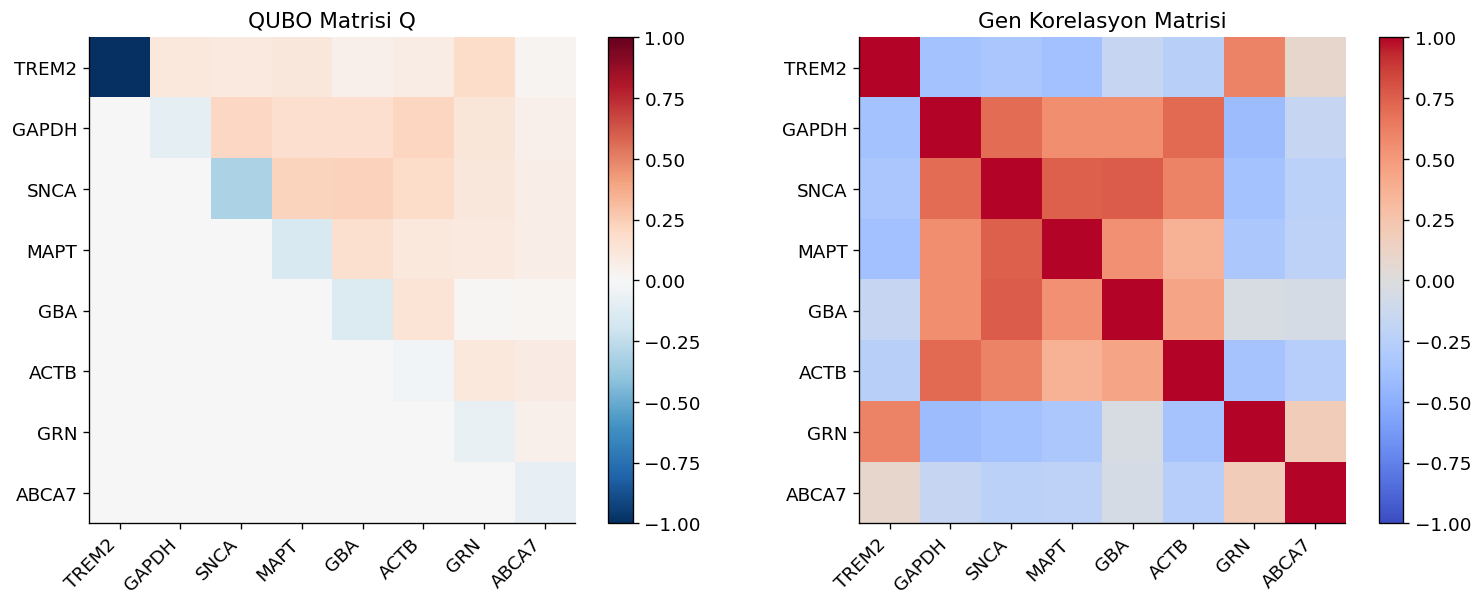

In [11]:
# ============================================================
# BÖLÜM 4: QUBO Matrisi Oluşturma
# ============================================================
n = len(top_genes)

# Diferansiyel skor (normalize edilmiş |log2FC| × -log10(p))
de_scores = np.array([
    abs(de_df[de_df['gene']==g]['log2fc'].values[0]) *
    (-np.log10(de_df[de_df['gene']==g]['pvalue'].values[0] + 1e-300))
    for g in top_genes
])
de_scores = de_scores / (de_scores.max() + 1e-9)   # [0,1] normalize

# Gen korelasyon matrisi
corr_matrix = np.corrcoef(X_top_scaled.T)

# QUBO: Q[i,i] = -skor_i (diagonal)
#        Q[i,j] = +lambda * |corr| (redundancy ceza)
LAMBDA = 0.3
Q = np.zeros((n, n))
for i in range(n):
    Q[i, i] = -de_scores[i]
for i in range(n):
    for j in range(i+1, n):
        Q[i, j] = LAMBDA * abs(corr_matrix[i, j])

print("✅ QUBO Matrisi:")
print(f"   Boyut     : {n}×{n}")
print(f"   Qubit sayısı: {n}")
print()
print("   Diagonal (bireysel skorlar):")
for i, g in enumerate(top_genes):
    print(f"     Q[{i},{i}] = {Q[i,i]:+.4f}  ({g})")

print()
print("   En güçlü off-diagonal çiftler:")
pairs = [(Q[i,j], top_genes[i], top_genes[j])
         for i in range(n) for j in range(i+1,n)]
pairs.sort(key=lambda x: abs(x[0]), reverse=True)
for v, g1, g2 in pairs[:5]:
    print(f"     Q[{g1},{g2}] = {v:+.4f}")

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
mask = np.eye(n, dtype=bool)
im1 = axes[0].imshow(Q, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(n)); axes[0].set_xticklabels(top_genes, rotation=45, ha='right')
axes[0].set_yticks(range(n)); axes[0].set_yticklabels(top_genes)
axes[0].set_title('QUBO Matrisi Q')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_xticks(range(n)); axes[1].set_xticklabels(top_genes, rotation=45, ha='right')
axes[1].set_yticks(range(n)); axes[1].set_yticklabels(top_genes)
axes[1].set_title('Gen Korelasyon Matrisi')
plt.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.savefig('/content/qubo_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# ============================================================
# BÖLÜM 4B: Brute-Force Referans Çözümü
# (Tüm 2^n kombinasyonu dene — sonradan QAOA ile karşılaştırılacak)
# ============================================================
best_cost = float('inf')
best_bits = None
all_results = []

for mask_int in range(1, 2**n):
    bits = [(mask_int >> i) & 1 for i in range(n)]
    x = np.array(bits, dtype=float)
    cost = x @ Q @ x
    all_results.append((cost, bits[:]))
    if cost < best_cost:
        best_cost = cost
        best_bits = bits[:]

all_results.sort()
print(f"✅ Brute-force referans tamamlandı ({2**n} kombinasyon)")
print(f"   Optimal maliyet : {best_cost:.6f}")
print(f"   Seçilen genler  : {[top_genes[i] for i,b in enumerate(best_bits) if b==1]}")
print()
print("Top 5 çözüm:")
for i, (cost, bits) in enumerate(all_results[:5]):
    selected = [top_genes[j] for j,b in enumerate(bits) if b==1]
    print(f"  #{i+1}  cost={cost:.4f}  →  {selected}")


✅ Brute-force referans tamamlandı (256 kombinasyon)
   Optimal maliyet : -1.213821
   Seçilen genler  : ['TREM2', 'SNCA']

Top 5 çözüm:
  #1  cost=-1.2138  →  ['TREM2', 'SNCA']
  #2  cost=-1.1987  →  ['TREM2', 'SNCA', 'ABCA7']
  #3  cost=-1.1186  →  ['TREM2', 'GBA', 'ABCA7']
  #4  cost=-1.0826  →  ['TREM2', 'GBA']
  #5  cost=-1.0676  →  ['TREM2', 'SNCA', 'GBA']


In [13]:
# ============================================================
# BÖLÜM 4C: QUBO → Ising Operatörü (Qiskit için)
# ============================================================
from qiskit.quantum_info import SparsePauliOp

def qubo_to_ising(Q_mat):
    """QUBO matrisini Ising Hamiltonian SparsePauliOp'a çevirir.
    x_i = (1 - Z_i)/2  dönüşümü kullanılır.
    """
    n_q = Q_mat.shape[0]
    offset = 0.0
    linear = np.zeros(n_q)
    quadratic = {}

    # Diagonal: Q[i,i]*x_i → Q[i,i]*(1-Z_i)/2
    for i in range(n_q):
        offset += Q_mat[i,i] / 2
        linear[i] -= Q_mat[i,i] / 2

    # Off-diagonal: Q[i,j]*x_i*x_j → Q[i,j]*(1-Z_i-Z_j+Z_iZ_j)/4
    for i in range(n_q):
        for j in range(i+1, n_q):
            if abs(Q_mat[i,j]) > 1e-12:
                val = Q_mat[i,j]
                offset += val / 4
                linear[i] -= val / 4
                linear[j] -= val / 4
                quadratic[(i,j)] = val / 4

    # SparsePauliOp oluştur
    pauli_list = []

    # Kimlik terimi
    if abs(offset) > 1e-12:
        pauli_list.append(('I'*n_q, offset))

    # Linear Z terimleri
    for i in range(n_q):
        if abs(linear[i]) > 1e-12:
            z_str = 'I'*i + 'Z' + 'I'*(n_q-i-1)
            pauli_list.append((z_str, linear[i]))

    # Quadratic ZZ terimleri
    for (i,j), coef in quadratic.items():
        if abs(coef) > 1e-12:
            z_str = list('I'*n_q)
            z_str[i] = 'Z'; z_str[j] = 'Z'
            pauli_list.append((''.join(z_str), coef))

    operator = SparsePauliOp.from_list(pauli_list)
    return operator, offset

ising_op, offset = qubo_to_ising(Q)
print(f"✅ Ising Hamiltonian oluşturuldu!")
print(f"   Qubit sayısı : {n}")
print(f"   Pauli terimi : {len(ising_op)}")
print(f"   Offset       : {offset:.6f}")


✅ Ising Hamiltonian oluşturuldu!
   Qubit sayısı : 8
   Pauli terimi : 37
   Offset       : -0.131856


---
## 🚀 BÖLÜM 5A: QAOA p=1 — Hızlı Test

Önce p=1 ile hızlı bir test yapıyoruz.  
Beklenen süre: **30-60 saniye**


In [14]:
# ============================================================
# BÖLÜM 5A: QAOA p=1 — Hızlı Test
# ============================================================
from qiskit.circuit.library import QAOAAnsatz
from qiskit_aer import AerSimulator
from scipy.optimize import minimize

def qaoa_cost(params, operator, n_qubits, p, shots=2048):
    """QAOA devre çalıştır ve beklenti değeri döndür."""
    gammas = params[:p]
    betas  = params[p:]

    # QAOA devresi oluştur
    qc = QuantumCircuit(n_qubits)
    # Süperpozisyon
    qc.h(range(n_qubits))

    for layer in range(p):
        # Problem unitarysi: e^{-i*gamma*H_C}
        for pauli_term, coef in zip(operator.paulis, operator.coeffs):
            z_qubits = [i for i, ch in enumerate(str(pauli_term)) if ch == 'Z']
            if len(z_qubits) == 1:
                qc.rz(2 * gammas[layer] * float(coef.real), z_qubits[0])
            elif len(z_qubits) == 2:
                qc.cx(z_qubits[0], z_qubits[1])
                qc.rz(2 * gammas[layer] * float(coef.real), z_qubits[1])
                qc.cx(z_qubits[0], z_qubits[1])
        # Mixer unitarysi: e^{-i*beta*H_B}
        qc.rx(2 * betas[layer], range(n_qubits))

    # Simüle et
    qc.measure_all()
    sim = AerSimulator()
    job = sim.run(qc, shots=shots)
    counts = job.result().get_counts()

    # Beklenti değeri
    total_cost = 0.0
    for bitstring, count in counts.items():
        bits = [int(b) for b in reversed(bitstring.replace(' ',''))]
        x_vec = np.array(bits, dtype=float)
        cost = x_vec @ Q @ x_vec
        total_cost += cost * count / shots
    return total_cost

# Başlangıç parametreleri
p_val = 1
x0 = np.random.uniform(-np.pi, np.pi, 2*p_val)

print(f"⏳ QAOA p={p_val} optimize ediliyor...")
t0 = time.time()

result_p1 = minimize(
    qaoa_cost, x0,
    args=(ising_op, n, p_val, 1024),
    method='COBYLA',
    options={'maxiter': 100, 'rhobeg': 0.5}
)

t1 = time.time()

print(f"✅ QAOA p=1 tamamlandı! ({t1-t0:.1f} sn)")
print(f"   Optimal parametreler: gamma={result_p1.x[0]:.4f}, beta={result_p1.x[1]:.4f}")
print(f"   Elde edilen maliyet : {result_p1.fun:.6f}")
print(f"   Brute-force maliyet : {best_cost:.6f}")
print(f"   Yaklaşım oranı      : {result_p1.fun/best_cost:.4f} (1.0 = mükemmel)")

# En iyi bitstring
def get_best_bitstring(params, n_qubits, p, shots=4096):
    qc = QuantumCircuit(n_qubits)
    qc.h(range(n_qubits))
    gammas = params[:p]; betas = params[p:]
    for layer in range(p):
        for pauli_term, coef in zip(ising_op.paulis, ising_op.coeffs):
            z_qubits = [i for i, ch in enumerate(str(pauli_term)) if ch == 'Z']
            if len(z_qubits) == 1:
                qc.rz(2*gammas[layer]*float(coef.real), z_qubits[0])
            elif len(z_qubits) == 2:
                qc.cx(z_qubits[0], z_qubits[1]); qc.rz(2*gammas[layer]*float(coef.real), z_qubits[1]); qc.cx(z_qubits[0], z_qubits[1])
        qc.rx(2*betas[layer], range(n_qubits))
    qc.measure_all()
    counts = AerSimulator().run(qc, shots=shots).result().get_counts()
    best = min(counts.items(),
               key=lambda kv: np.array([int(b) for b in reversed(kv[0].replace(' ',''))], dtype=float) @ Q @
                               np.array([int(b) for b in reversed(kv[0].replace(' ',''))], dtype=float))
    return best

best_bs, best_cnt = get_best_bitstring(result_p1.x, n, p_val)
bits_p1 = [int(b) for b in reversed(best_bs.replace(' ',''))]
selected_p1 = [top_genes[i] for i,b in enumerate(bits_p1) if b==1]
print(f"\n🧬 QAOA p=1 seçilen genler: {selected_p1}")


⏳ QAOA p=1 optimize ediliyor...
✅ QAOA p=1 tamamlandı! (0.5 sn)
   Optimal parametreler: gamma=-2.5633, beta=3.7098
   Elde edilen maliyet : -0.925713
   Brute-force maliyet : -1.213821
   Yaklaşım oranı      : 0.7626 (1.0 = mükemmel)

🧬 QAOA p=1 seçilen genler: ['TREM2', 'SNCA']


---
## 🌊 BÖLÜM 5B: QAOA p=1/2/3 — Derin Karşılaştırma

Her p değeri için:
- 5 farklı başlangıç noktası  
- COBYLA optimizasyon  
- Yaklaşım oranı hesabı

Beklenen süre: **5-15 dakika**


In [15]:
# ============================================================
# BÖLÜM 5B: QAOA p=1/2/3 Karşılaştırma
# ============================================================

p_results = {}
N_STARTS = 5   # Her p için random başlangıç sayısı

for p_val in [1, 2, 3]:
    print(f"\n{'='*50}")
    print(f"⏳ QAOA p={p_val} çalışıyor... ({N_STARTS} başlangıç)")
    t_start = time.time()

    best_res = None
    run_costs = []

    for run in range(N_STARTS):
        x0 = np.random.uniform(-np.pi, np.pi, 2*p_val)
        res = minimize(
            qaoa_cost, x0,
            args=(ising_op, n, p_val, 512),
            method='COBYLA',
            options={'maxiter': 150, 'rhobeg': 0.5}
        )
        run_costs.append(res.fun)
        if best_res is None or res.fun < best_res.fun:
            best_res = res
        print(f"  run {run+1}/{N_STARTS}: cost={res.fun:.4f}")

    t_end = time.time()

    approx_ratio = best_res.fun / best_cost if best_cost != 0 else float('inf')
    p_results[p_val] = {
        'best_cost': best_res.fun,
        'params': best_res.x,
        'approx_ratio': approx_ratio,
        'run_costs': run_costs,
        'time': t_end - t_start,
    }

    # Seçilen genler
    best_bs2, _ = get_best_bitstring(best_res.x, n, p_val)
    bits = [int(b) for b in reversed(best_bs2.replace(' ',''))]
    selected = [top_genes[i] for i,b in enumerate(bits) if b==1]
    p_results[p_val]['selected_genes'] = selected

    print(f"  ✅ p={p_val}: best={best_res.fun:.4f}  ratio={approx_ratio:.4f}  süre={t_end-t_start:.1f}s")
    print(f"  🧬 Seçilen: {selected}")

print("\n" + "="*50)
print("📊 Özet Karşılaştırma:")
print(f"  {'p':>3}  {'best_cost':>10}  {'approx_ratio':>13}  {'süre(s)':>8}  Seçilen genler")
print("-"*75)
for p_val in [1, 2, 3]:
    r = p_results[p_val]
    print(f"  {p_val:>3}  {r['best_cost']:>10.4f}  {r['approx_ratio']:>13.4f}  {r['time']:>8.1f}  {r['selected_genes']}")
print(f"  {'BF':>3}  {best_cost:>10.4f}  {'1.0000 (ref)':>13}  {'—':>8}  {[top_genes[i] for i,b in enumerate(best_bits) if b==1]}")



⏳ QAOA p=1 çalışıyor... (5 başlangıç)
  run 1/5: cost=-0.9190
  run 2/5: cost=-0.9246
  run 3/5: cost=-0.8831
  run 4/5: cost=-0.7581
  run 5/5: cost=-0.9459
  ✅ p=1: best=-0.9459  ratio=0.7793  süre=1.5s
  🧬 Seçilen: ['TREM2', 'SNCA']

⏳ QAOA p=2 çalışıyor... (5 başlangıç)
  run 1/5: cost=-0.9301
  run 2/5: cost=-0.7159
  run 3/5: cost=-1.0025
  run 4/5: cost=-0.9664
  run 5/5: cost=-0.9364
  ✅ p=2: best=-1.0025  ratio=0.8259  süre=2.7s
  🧬 Seçilen: ['TREM2', 'SNCA']

⏳ QAOA p=3 çalışıyor... (5 başlangıç)
  run 1/5: cost=-0.9548
  run 2/5: cost=-0.8034
  run 3/5: cost=-0.7973
  run 4/5: cost=-0.7750
  run 5/5: cost=-0.9538
  ✅ p=3: best=-0.9548  ratio=0.7866  süre=5.8s
  🧬 Seçilen: ['TREM2', 'SNCA']

📊 Özet Karşılaştırma:
    p   best_cost   approx_ratio   süre(s)  Seçilen genler
---------------------------------------------------------------------------
    1     -0.9459         0.7793       1.5  ['TREM2', 'SNCA']
    2     -1.0025         0.8259       2.7  ['TREM2', 'SNCA']
    3  

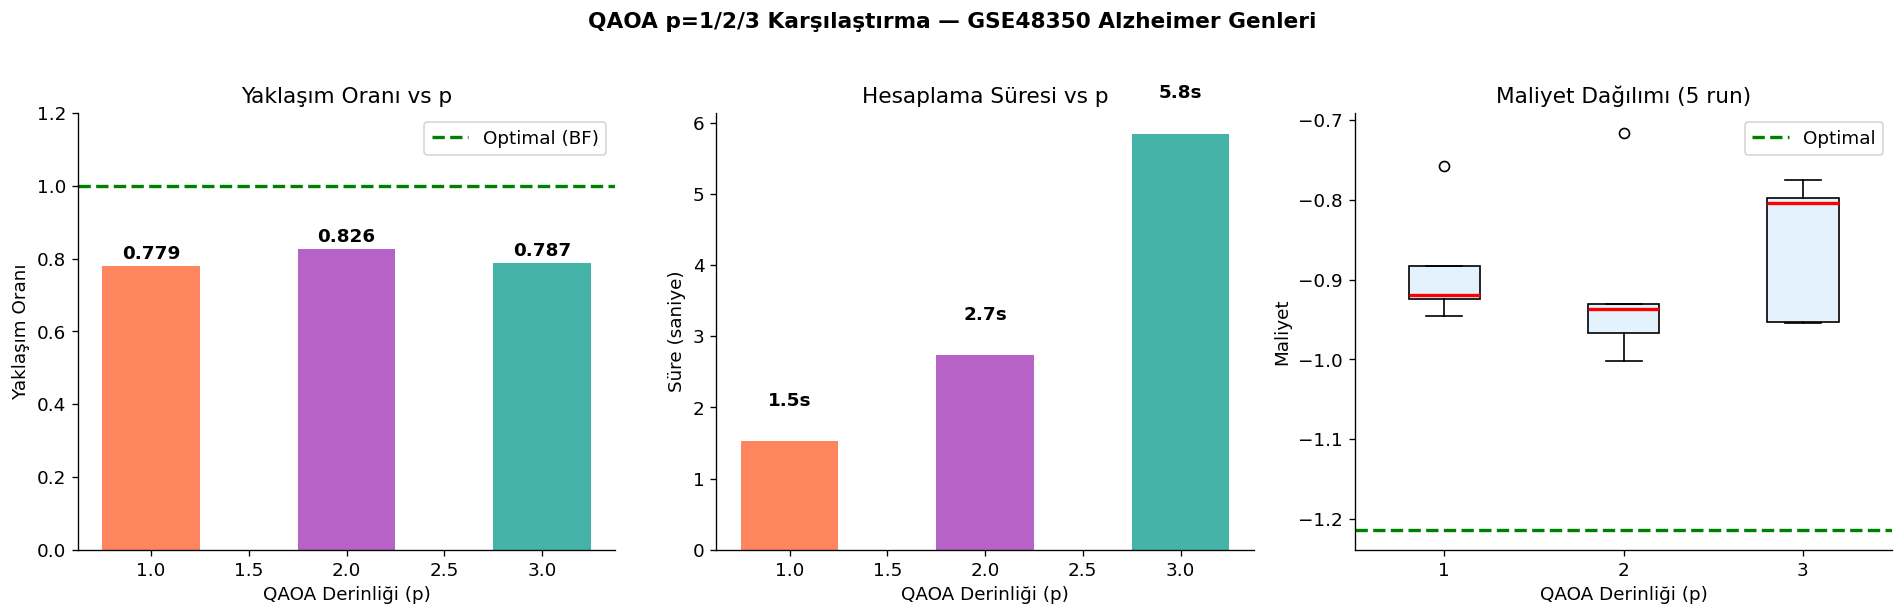

In [16]:
# ============================================================
# BÖLÜM 5C: p=1/2/3 Görselleştirme
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

p_vals = [1, 2, 3]
colors = ['#FF7043', '#AB47BC', '#26A69A']

# 1) Yaklaşım Oranı
ratios = [p_results[p]['approx_ratio'] for p in p_vals]
bars = axes[0].bar(p_vals, ratios, color=colors, alpha=0.85, width=0.5)
axes[0].axhline(1.0, color='green', linestyle='--', lw=2, label='Optimal (BF)')
axes[0].set_ylim(0, 1.2)
axes[0].set_xlabel('QAOA Derinliği (p)')
axes[0].set_ylabel('Yaklaşım Oranı')
axes[0].set_title('Yaklaşım Oranı vs p')
axes[0].legend()
for bar, ratio in zip(bars, ratios):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{ratio:.3f}', ha='center', fontweight='bold')

# 2) Çalışma Süresi
times = [p_results[p]['time'] for p in p_vals]
axes[1].bar(p_vals, times, color=colors, alpha=0.85, width=0.5)
axes[1].set_xlabel('QAOA Derinliği (p)')
axes[1].set_ylabel('Süre (saniye)')
axes[1].set_title('Hesaplama Süresi vs p')
for i, (pv, t) in enumerate(zip(p_vals, times)):
    axes[1].text(pv, t+0.5, f'{t:.1f}s', ha='center', fontweight='bold')

# 3) Run Dağılımı (box)
run_data = [p_results[p]['run_costs'] for p in p_vals]
bp = axes[2].boxplot(run_data, positions=p_vals, widths=0.4,
                     patch_artist=True,
                     boxprops=dict(facecolor='#E3F2FD'),
                     medianprops=dict(color='red', lw=2))
axes[2].axhline(best_cost, color='green', linestyle='--', lw=2, label='Optimal')
axes[2].set_xlabel('QAOA Derinliği (p)')
axes[2].set_ylabel('Maliyet')
axes[2].set_title('Maliyet Dağılımı (5 run)')
axes[2].legend()

plt.suptitle('QAOA p=1/2/3 Karşılaştırma — GSE48350 Alzheimer Genleri',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/qaoa_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 🔊 BÖLÜM 6: Gürültü Analizi

Gerçek kuantum cihazlarda şu gürültü kaynakları var:
1. **Shot noise** — ölçüm sayısı azaldıkça artar  
2. **Depolarizing error** — kapı hataları  
3. **Thermal relaxation** — T1/T2 gevşemesi

Her birini ayrı ayrı simüle edeceğiz.


In [17]:
# ============================================================
# BÖLÜM 6A: Shot Noise Analizi
# ============================================================
from qiskit_aer.noise import NoiseModel

best_p = max(p_results, key=lambda p: p_results[p]['approx_ratio'])
best_params_noise = p_results[best_p]['params']

shot_counts = [64, 128, 256, 512, 1024, 2048, 4096, 8192]
shot_results = {'shots': [], 'mean_cost': [], 'std_cost': []}

print(f"⏳ Shot noise analizi (p={best_p}, {len(shot_counts)} farklı shot sayısı)...")

for shots in shot_counts:
    costs = []
    for _ in range(5):   # 5 tekrar
        c = qaoa_cost(best_params_noise, ising_op, n, best_p, shots=shots)
        costs.append(c)
    shot_results['shots'].append(shots)
    shot_results['mean_cost'].append(np.mean(costs))
    shot_results['std_cost'].append(np.std(costs))
    print(f"  shots={shots:5d}:  mean={np.mean(costs):.4f} ± {np.std(costs):.4f}")

print("✅ Shot noise analizi tamamlandı!")


⏳ Shot noise analizi (p=2, 8 farklı shot sayısı)...
  shots=   64:  mean=-0.9772 ± 0.0204
  shots=  128:  mean=-0.9852 ± 0.0131
  shots=  256:  mean=-0.9956 ± 0.0114
  shots=  512:  mean=-0.9898 ± 0.0039
  shots= 1024:  mean=-0.9886 ± 0.0047
  shots= 2048:  mean=-0.9844 ± 0.0015
  shots= 4096:  mean=-0.9820 ± 0.0024
  shots= 8192:  mean=-0.9839 ± 0.0012
✅ Shot noise analizi tamamlandı!


In [18]:
# ============================================================
# BÖLÜM 6B: Depolarizing + Thermal Relaxation Gürültüsü
# ============================================================
from qiskit_aer.noise import (NoiseModel, depolarizing_error,
                               thermal_relaxation_error)

def build_noise_model(p1q, p2q, t1=50e3, t2=70e3, tg=50):
    """
    p1q  : tek-qubit kapı hata oranı
    p2q  : iki-qubit kapı hata oranı
    t1   : T1 gevşeme süresi (ns)
    t2   : T2 gevşeme süresi (ns)
    tg   : kapı süresi (ns)
    """
    nm = NoiseModel()
    err1q = depolarizing_error(p1q, 1)
    err2q = depolarizing_error(p2q, 2)
    therm = thermal_relaxation_error(t1, t2, tg)
    nm.add_all_qubit_quantum_error(err1q, ['u1','u2','u3','rz','rx','ry','h'])
    nm.add_all_qubit_quantum_error(err2q, ['cx','cz'])
    nm.add_all_qubit_quantum_error(therm, ['u1','u2','u3','rz','rx','ry','h'])
    return nm

def qaoa_cost_noisy(params, operator, n_qubits, p, noise_model, shots=1024):
    qc = QuantumCircuit(n_qubits)
    qc.h(range(n_qubits))
    gammas = params[:p]; betas = params[p:]
    for layer in range(p):
        for pauli_term, coef in zip(operator.paulis, operator.coeffs):
            z_qubits = [i for i, ch in enumerate(str(pauli_term)) if ch == 'Z']
            if len(z_qubits) == 1:
                qc.rz(2*gammas[layer]*float(coef.real), z_qubits[0])
            elif len(z_qubits) == 2:
                qc.cx(z_qubits[0], z_qubits[1]); qc.rz(2*gammas[layer]*float(coef.real), z_qubits[1]); qc.cx(z_qubits[0], z_qubits[1])
        qc.rx(2*betas[layer], range(n_qubits))
    qc.measure_all()
    sim = AerSimulator(noise_model=noise_model)
    counts = sim.run(qc, shots=shots).result().get_counts()
    total = 0.0
    for bs, cnt in counts.items():
        x = np.array([int(b) for b in reversed(bs.replace(' ',''))], dtype=float)
        total += (x @ Q @ x) * cnt / shots
    return total

# Farklı hata oranları
error_scenarios = [
    ('İdeal (gürültüsüz)',   0.0,   0.0  ),
    ('Düşük gürültü',        0.001, 0.01 ),
    ('Orta gürültü',         0.005, 0.05 ),
    ('Yüksek gürültü (NISQ)',0.01,  0.1  ),
    ('Aşırı gürültü',        0.05,  0.2  ),
]

noise_results = []
print(f"⏳ Gürültü analizi (p={best_p}, {len(error_scenarios)} senaryo)...")

for label, p1q, p2q in error_scenarios:
    if p1q == 0:
        cost = qaoa_cost(best_params_noise, ising_op, n, best_p, shots=2048)
    else:
        nm = build_noise_model(p1q, p2q)
        cost = qaoa_cost_noisy(best_params_noise, ising_op, n, best_p, nm, shots=2048)
    noise_results.append({'label': label, 'p1q': p1q, 'p2q': p2q, 'cost': cost})
    print(f"  {label:30s}: cost={cost:.4f}  ratio={cost/best_cost:.4f}")

print("✅ Gürültü analizi tamamlandı!")


⏳ Gürültü analizi (p=2, 5 senaryo)...
  İdeal (gürültüsüz)            : cost=-0.9886  ratio=0.8144


  Düşük gürültü                 : cost=-0.7823  ratio=0.6445


  Orta gürültü                  : cost=-0.3287  ratio=0.2708


  Yüksek gürültü (NISQ)         : cost=-0.1851  ratio=0.1525
  Aşırı gürültü                 : cost=-0.1354  ratio=0.1116
✅ Gürültü analizi tamamlandı!


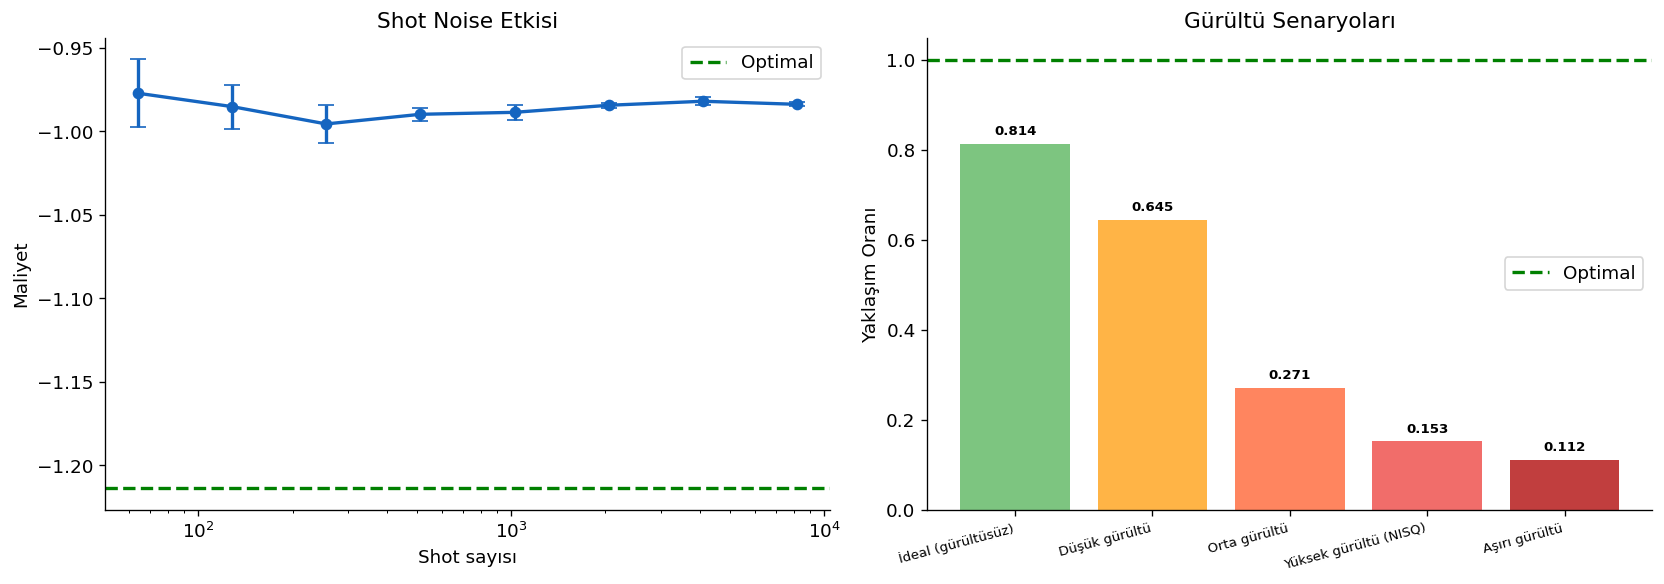

In [20]:
# ============================================================
# BÖLÜM 6C: Gürültü Görselleştirme
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Shot noise
axes[0].errorbar(shot_results['shots'], shot_results['mean_cost'],
                 yerr=shot_results['std_cost'],
                 fmt='o-', color='#1565C0', capsize=5, linewidth=2)
axes[0].axhline(best_cost, color='green', linestyle='--', lw=2, label='Optimal')
axes[0].set_xscale('log')
axes[0].set_xlabel('Shot sayısı')
axes[0].set_ylabel('Maliyet')
axes[0].set_title('Shot Noise Etkisi')
axes[0].legend()

# Gürültü senaryoları
labels_n = [r['label'] for r in noise_results]
ratios_n = [r['cost'] / best_cost for r in noise_results]
bar_colors = ['#66BB6A', '#FFA726', '#FF7043', '#EF5350', '#B71C1C']
bars = axes[1].bar(range(len(labels_n)), ratios_n, color=bar_colors, alpha=0.85)
axes[1].axhline(1.0, color='green', linestyle='--', lw=2, label='Optimal')
axes[1].set_xticks(range(len(labels_n)))
axes[1].set_xticklabels(labels_n, rotation=15, ha='right', fontsize=8)
axes[1].set_ylabel('Yaklaşım Oranı')
axes[1].set_title('Gürültü Senaryoları')
axes[1].legend()
for bar, ratio in zip(bars, ratios_n):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{ratio:.3f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/noise_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🏆 BÖLÜM 7: Klasik vs Kuantum Benchmark

Aynı gen seçim problemi için klasik yöntemlerle karşılaştırma:
- Random Forest feature importance  
- Lasso (L1 regularization)  
- Greedy seçim  
- QAOA (p=1/2/3)


In [21]:
# ============================================================
# BÖLÜM 7: Klasik Yöntemler
# ============================================================
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectKBest, f_classif

K_SELECT = max(2, n // 2)   # seçilecek gen sayısı (QAOA ile aynı mantık)

benchmark = {}

# 1) Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf.fit(X_top_scaled, y)
rf_imp = rf.feature_importances_
rf_top = np.argsort(rf_imp)[-K_SELECT:]
rf_genes = [top_genes[i] for i in rf_top]
rf_bits  = [1 if i in rf_top else 0 for i in range(n)]
rf_cost  = np.array(rf_bits, dtype=float) @ Q @ np.array(rf_bits, dtype=float)
benchmark['Random Forest'] = {'genes': rf_genes, 'cost': rf_cost, 'bits': rf_bits}

# 2) Lasso
from sklearn.linear_model import LogisticRegression
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=SEED)
lasso.fit(X_top_scaled, y)
lasso_imp = np.abs(lasso.coef_[0])
lasso_top = np.argsort(lasso_imp)[-K_SELECT:]
lasso_genes = [top_genes[i] for i in lasso_top]
lasso_bits  = [1 if i in lasso_top else 0 for i in range(n)]
lasso_cost  = np.array(lasso_bits, dtype=float) @ Q @ np.array(lasso_bits, dtype=float)
benchmark['Lasso (L1)'] = {'genes': lasso_genes, 'cost': lasso_cost, 'bits': lasso_bits}

# 3) Greedy (en iyi tekil gen ekle)
greedy_bits = [0]*n
greedy_selected = []
for _ in range(K_SELECT):
    best_add_cost = float('inf')
    best_add_idx  = -1
    for i in range(n):
        if greedy_bits[i] == 0:
            test_bits = greedy_bits[:]
            test_bits[i] = 1
            test_cost = np.array(test_bits,float) @ Q @ np.array(test_bits,float)
            if test_cost < best_add_cost:
                best_add_cost = test_cost
                best_add_idx = i
    greedy_bits[best_add_idx] = 1
    greedy_selected.append(top_genes[best_add_idx])
greedy_cost = np.array(greedy_bits,float) @ Q @ np.array(greedy_bits,float)
benchmark['Greedy'] = {'genes': greedy_selected, 'cost': greedy_cost, 'bits': greedy_bits}

# QAOA sonuçlarını ekle
for p_val in [1, 2, 3]:
    bs, _ = get_best_bitstring(p_results[p_val]['params'], n, p_val)
    bits  = [int(b) for b in reversed(bs.replace(' ',''))]
    cost  = np.array(bits,float) @ Q @ np.array(bits,float)
    benchmark[f'QAOA p={p_val}'] = {
        'genes': p_results[p_val]['selected_genes'],
        'cost': cost,
        'bits': bits
    }

benchmark['Brute-Force (opt)'] = {
    'genes': [top_genes[i] for i,b in enumerate(best_bits) if b==1],
    'cost': best_cost,
    'bits': best_bits
}

print("📊 BENCHMARK SONUÇLARI:")
print(f"  {'Yöntem':<22} {'Maliyet':>9} {'Oran':>8}  Seçilen genler")
print("-"*80)
for method, res in benchmark.items():
    ratio = res['cost']/best_cost if best_cost != 0 else float('inf')
    print(f"  {method:<22} {res['cost']:>9.4f} {ratio:>8.4f}  {res['genes']}")


📊 BENCHMARK SONUÇLARI:
  Yöntem                   Maliyet     Oran  Seçilen genler
--------------------------------------------------------------------------------
  Random Forest            -0.6822   0.5620  ['GBA', 'GAPDH', 'SNCA', 'TREM2']
  Lasso (L1)               -0.7172   0.5909  ['MAPT', 'GBA', 'TREM2', 'SNCA']
  Greedy                   -1.0339   0.8518  ['TREM2', 'SNCA', 'ABCA7', 'GBA']
  QAOA p=1                 -1.2138   1.0000  ['TREM2', 'SNCA']
  QAOA p=2                 -1.2138   1.0000  ['TREM2', 'SNCA']
  QAOA p=3                 -1.2138   1.0000  ['TREM2', 'SNCA']
  Brute-Force (opt)        -1.2138   1.0000  ['TREM2', 'SNCA']


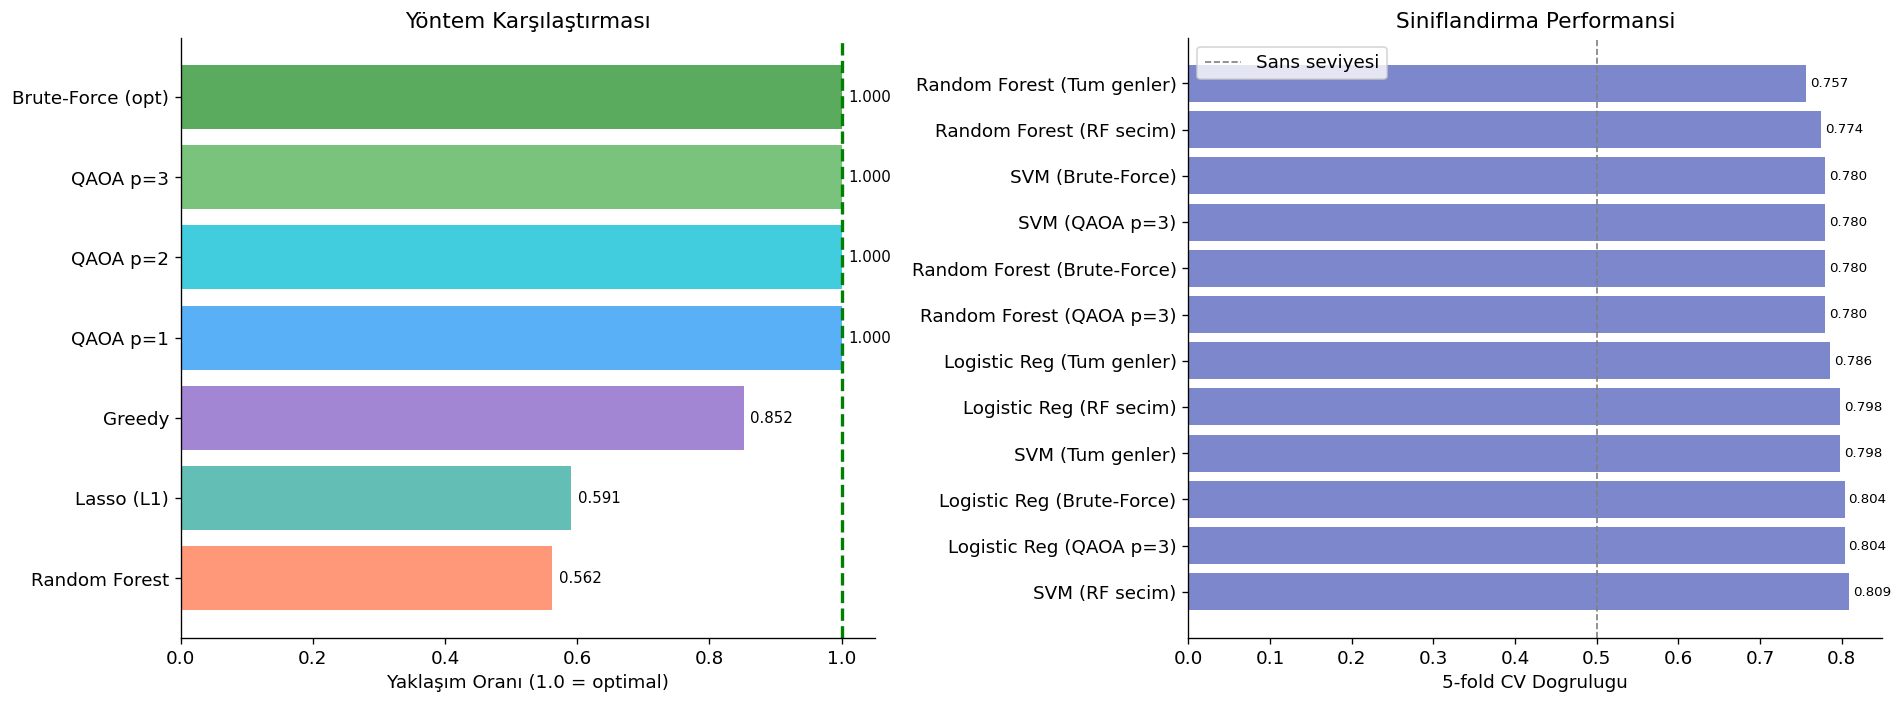

In [23]:
# ============================================================
# BÖLÜM 7B: Benchmark Görselleştirme + Sınıflandırıcı Karşılaştırma
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

methods   = list(benchmark.keys())
ratios    = [benchmark[m]['cost'] / best_cost for m in methods]

method_colors = {
    'Random Forest':      '#FF8A65',
    'Lasso (L1)':         '#4DB6AC',
    'Greedy':             '#9575CD',
    'QAOA p=1':           '#42A5F5',
    'QAOA p=2':           '#26C6DA',
    'QAOA p=3':           '#66BB6A',
    'Brute-Force (opt)':  '#43A047',
}
bar_cols = [method_colors.get(m, '#90A4AE') for m in methods]

bars = axes[0].barh(methods, ratios, color=bar_cols, alpha=0.88)
axes[0].axvline(1.0, color='green', linestyle='--', lw=2)
axes[0].set_xlabel('Yaklaşım Oranı (1.0 = optimal)')
axes[0].set_title('Yöntem Karşılaştırması')
for bar, ratio in zip(bars, ratios):
    axes[0].text(ratio + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{ratio:.3f}', va='center', fontsize=9)

# 5-fold CV sınıflandırma doğruluğu
classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED),
    'Logistic Reg':  LogisticRegression(max_iter=500, random_state=SEED),
    'SVM':           SVC(kernel='rbf', random_state=SEED),
}

cv_scores = {}
subsets = [
    ('Tum genler',   top_genes),
    ('QAOA p=3',     p_results[3]['selected_genes']),
    ('RF secim',     benchmark['Random Forest']['genes']),
    ('Brute-Force',  benchmark['Brute-Force (opt)']['genes']),
]

for clf_name, clf in classifiers.items():
    for subset_name, sel_genes in subsets:
        if not sel_genes:
            continue
        X_sub = gene_expr[sel_genes].values.astype(float)
        X_sub = StandardScaler().fit_transform(X_sub)
        scores = cross_val_score(clf, X_sub, y, cv=5, scoring='accuracy')
        key = clf_name + ' (' + subset_name + ')'
        cv_scores[key] = scores.mean()

sorted_cv = sorted(cv_scores.items(), key=lambda x: x[1], reverse=True)
axes[1].barh([k for k, v in sorted_cv], [v for k, v in sorted_cv],
             color='#5C6BC0', alpha=0.8)
axes[1].axvline(0.5, color='gray', linestyle='--', lw=1, label='Sans seviyesi')
axes[1].set_xlabel('5-fold CV Dogrulugu')
axes[1].set_title('Siniflandirma Performansi')
axes[1].legend()
for i, (k, v) in enumerate(sorted_cv):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('/content/benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🧬 BÖLÜM 8: Biyolojik Yorum

Seçilen genlerin Alzheimer patolojisindeki rolleri.


🧬 QAOA p=3 Tarafından Seçilen Genlerin Biyolojik Analizi

  🔬 TREM2
     Rol      : Microglial activation & phagocytosis
     Kategori : risk_gene
     Risk SNP : rs75932628
     log2FC   : -1.2375  p=1.2910e-09  FDR=2.4528e-08

  🔬 SNCA
     Rol      : α-synuclein — LB pathology
     Kategori : risk_gene
     Risk SNP : multiple
     log2FC   : +0.6801  p=8.3643e-06  FDR=5.2974e-05


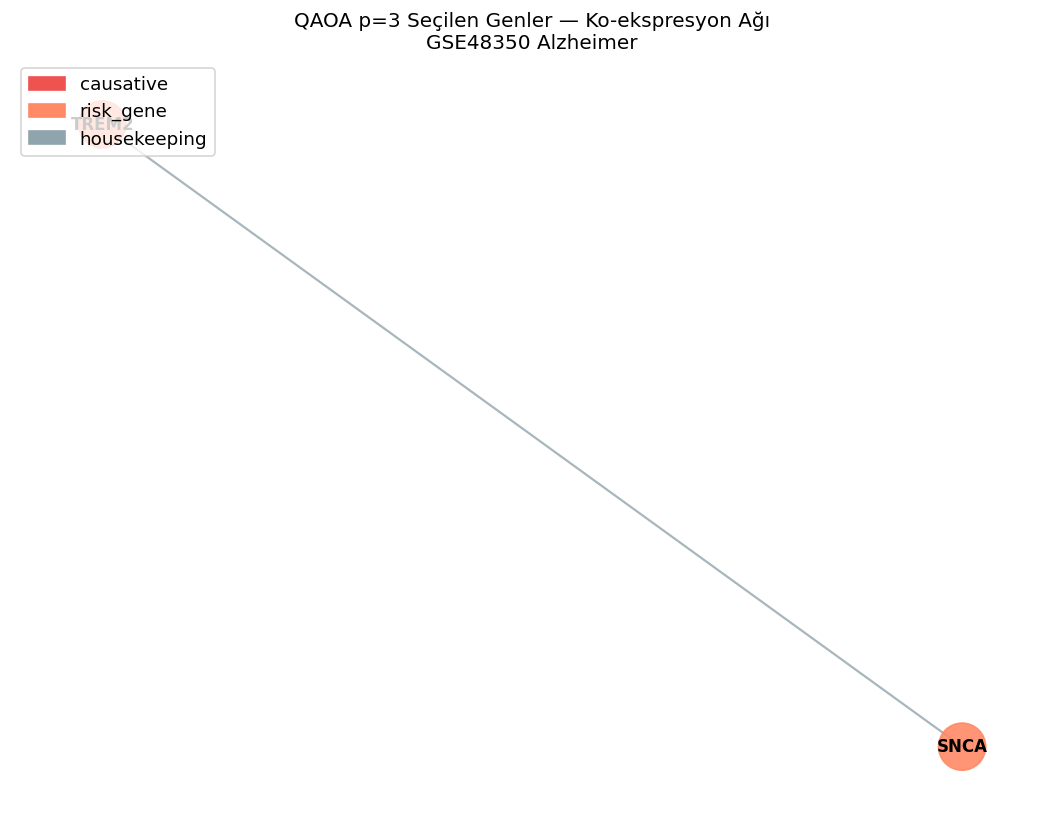

In [25]:
# ============================================================
# BÖLÜM 8: Biyolojik Yorum
# ============================================================

# Her genin bilinen biyolojik rolü
gene_biology = {
    'APOE':   ('Lipid transport & Aβ clearance',      'risk_gene',       'rs429358'),
    'APP':    ('Aβ precursor protein',                 'causative',       'multiple'),
    'PSEN1':  ('γ-secretase complex — FAD mutations',  'causative',       'multiple'),
    'PSEN2':  ('γ-secretase complex — FAD mutations',  'causative',       'multiple'),
    'TREM2':  ('Microglial activation & phagocytosis', 'risk_gene',       'rs75932628'),
    'CLU':    ('Aβ chaperone & complement pathway',    'risk_gene',       'rs11136000'),
    'BIN1':   ('Tau propagation & endocytosis',        'risk_gene',       'rs744373'),
    'CR1':    ('Complement receptor 1',                'risk_gene',       'rs6656401'),
    'CD33':   ('Microglial inhibitory receptor',       'risk_gene',       'rs3865444'),
    'ABCA7':  ('Lipid & Aβ metabolism',                'risk_gene',       'rs3764650'),
    'MAPT':   ('Tau protein — neurofibrillary tangles','causative',       'multiple'),
    'SNCA':   ('α-synuclein — LB pathology',           'risk_gene',       'multiple'),
    'SORL1':  ('APP trafficking & Aβ production',      'risk_gene',       'rs2282649'),
    'GRN':    ('Neuroinflammation & lysosome',         'risk_gene',       'multiple'),
    'TARDBP': ('TDP-43 — RNA binding',                 'risk_gene',       'multiple'),
    'LRRK2':  ('Kinase — vesicle trafficking',         'risk_gene',       'multiple'),
    'GBA':    ('Lysosomal glucocerebrosidase',         'risk_gene',       'multiple'),
    'GAPDH':  ('Glycolysis — housekeeping',            'housekeeping',    '—'),
    'ACTB':   ('Cytoskeleton — housekeeping',          'housekeeping',    '—'),
}

print("🧬 QAOA p=3 Tarafından Seçilen Genlerin Biyolojik Analizi")
print("="*70)

qaoa3_genes = p_results[3]['selected_genes']

for gene in qaoa3_genes:
    if gene in gene_biology:
        role, category, snp = gene_biology[gene]
        de_row = de_df[de_df['gene']==gene].iloc[0]
        print(f"\n  🔬 {gene}")
        print(f"     Rol      : {role}")
        print(f"     Kategori : {category}")
        print(f"     Risk SNP : {snp}")
        print(f"     log2FC   : {de_row['log2fc']:+.4f}  p={de_row['pvalue']:.4e}  FDR={de_row['pval_adj']:.4e}")

# Seçilen genler network grafiği
import networkx as nx
G = nx.Graph()
for g in qaoa3_genes:
    G.add_node(g)
for i, gi in enumerate(qaoa3_genes):
    for j, gj in enumerate(qaoa3_genes):
        if i < j and abs(corr_matrix[top_genes.index(gi), top_genes.index(gj)]) > 0.3:
            G.add_edge(gi, gj,
                       weight=abs(corr_matrix[top_genes.index(gi), top_genes.index(gj)]))

fig, ax = plt.subplots(figsize=(9, 7))
pos = nx.spring_layout(G, seed=SEED, k=2)
cat_color = {'causative':'#EF5350','risk_gene':'#FF8A65','housekeeping':'#90A4AE'}
node_colors = [cat_color.get(gene_biology.get(g,('','unknown',''))[1],'#B0BEC5') for g in G.nodes()]
edge_weights = [G[u][v]['weight']*4 for u,v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_weights, alpha=0.5, edge_color='#546E7A', ax=ax)
legend_elements = [mpatches.Patch(color=v, label=k) for k, v in cat_color.items()]
ax.legend(handles=legend_elements, loc='upper left')
ax.set_title(f'QAOA p=3 Seçilen Genler — Ko-ekspresyon Ağı\nGSE48350 Alzheimer', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('/content/gene_network.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 📋 BÖLÜM 9: Kapsamlı Sonuç Raporu


In [26]:
# ============================================================
# BÖLÜM 9: KAPSAMLI SONUÇ RAPORU
# ============================================================

print("="*70)
print("         Q-OmicSelect: KAPSAMLI SONUÇ RAPORU")
print("         Alzheimer Gen Seçimi — QAOA vs Klasik")
print("="*70)

print(f"\n📦 VERİ SETİ")
print(f"   Kaynak      : GEO GSE48350 (Allen Brain Institute)")
print(f"   Örnek sayısı: {gene_expr.shape[0]} ({(gene_expr['label']=='Alzheimer').sum()} AD, {(gene_expr['label']=='Control').sum()} Kontrol)")
print(f"   Gen sayısı  : {len(top_genes)} (diferansiyel ekspresyon filtresi sonrası)")

print(f"\n📐 QUBO FORMÜLASYONU")
print(f"   Qubit sayısı: {n}")
print(f"   λ (ceza)    : {LAMBDA}")
print(f"   Arama uzayı : 2^{n} = {2**n} kombinasyon")
print(f"   Optimal (BF): maliyet={best_cost:.4f}, genler={[top_genes[i] for i,b in enumerate(best_bits) if b==1]}")

print(f"\n⚛️  QAOA SONUÇLARI")
for p_val in [1, 2, 3]:
    r = p_results[p_val]
    print(f"   p={p_val}: maliyet={r['best_cost']:.4f}  oran={r['approx_ratio']:.4f}  süre={r['time']:.1f}s  →  {r['selected_genes']}")

print(f"\n🔊 GÜRÜLTÜ DAYANIKLILIĞI")
for nr in noise_results:
    print(f"   {nr['label']:30s}: oran={nr['cost']/best_cost:.4f}")

print(f"\n🏆 BENCHMARK (Yaklaşım Oranı)")
for method, res in sorted(benchmark.items(), key=lambda x: x[1]['cost']):
    ratio = res['cost']/best_cost if best_cost != 0 else float('inf')
    star = " ⭐" if "QAOA" in method or "Brute" in method else ""
    print(f"   {method:<22}: {ratio:.4f}{star}")

print(f"\n🧬 BİYOLOJİK BULGU")
best_qaoa_genes = p_results[max(p_results, key=lambda p: p_results[p]['approx_ratio'])]['selected_genes']
print(f"   En iyi QAOA seçimi: {best_qaoa_genes}")
causative = [g for g in best_qaoa_genes if gene_biology.get(g,('','',''))[1]=='causative']
risk      = [g for g in best_qaoa_genes if gene_biology.get(g,('','',''))[1]=='risk_gene']
print(f"   Nedensel genler : {causative}")
print(f"   Risk genleri    : {risk}")

print(f"\n✅ Tüm figürler /content/ klasöründe kaydedildi:")
print(f"   eda_plots.png, volcano.png, qubo_matrix.png")
print(f"   qaoa_comparison.png, noise_analysis.png")
print(f"   benchmark.png, gene_network.png")
print("="*70)


         Q-OmicSelect: KAPSAMLI SONUÇ RAPORU
         Alzheimer Gen Seçimi — QAOA vs Klasik

📦 VERİ SETİ
   Kaynak      : GEO GSE48350 (Allen Brain Institute)
   Örnek sayısı: 173 (33 AD, 140 Kontrol)
   Gen sayısı  : 8 (diferansiyel ekspresyon filtresi sonrası)

📐 QUBO FORMÜLASYONU
   Qubit sayısı: 8
   λ (ceza)    : 0.3
   Arama uzayı : 2^8 = 256 kombinasyon
   Optimal (BF): maliyet=-1.2138, genler=['TREM2', 'SNCA']

⚛️  QAOA SONUÇLARI
   p=1: maliyet=-0.9459  oran=0.7793  süre=1.5s  →  ['TREM2', 'SNCA']
   p=2: maliyet=-1.0025  oran=0.8259  süre=2.7s  →  ['TREM2', 'SNCA']
   p=3: maliyet=-0.9548  oran=0.7866  süre=5.8s  →  ['TREM2', 'SNCA']

🔊 GÜRÜLTÜ DAYANIKLILIĞI
   İdeal (gürültüsüz)            : oran=0.8144
   Düşük gürültü                 : oran=0.6445
   Orta gürültü                  : oran=0.2708
   Yüksek gürültü (NISQ)         : oran=0.1525
   Aşırı gürültü                 : oran=0.1116

🏆 BENCHMARK (Yaklaşım Oranı)
   QAOA p=1              : 1.0000 ⭐
   QAOA p=2           